# Exercício 8.2 — Visualização de Embeddings com t-SNE

Exercício do *Mini-Lab: Embeddings e Vetores com BERT* (seção 8.2).

**Objetivo:** explorar a projeção 2D dos embeddings (SBERT) e verificar se textos do mesmo tema formam agrupamentos (clusters) no mapa.

## Contexto

- Embeddings têm alta dimensão (384, 768...). Para "ver" padrões, projetamos para 2D.
- **t-SNE** tenta manter **vizinhanças locais**: pontos próximos em alta dimensão tendem a ficar próximos em 2D.
- É ótimo para enxergar clusters; **não preserva distâncias globais** e pode variar entre execuções.
- Parâmetro importante: `perplexity` (ex.: 10, 15, 20) — controla a granularidade dos agrupamentos.

Este notebook é autocontido e usa o mesmo dataset do mini‑lab. Execute as células em ordem.

## 1) Imports

In [1]:
import numpy as np
import pandas as pd

from sklearn.manifold import TSNE

import matplotlib.pyplot as plt

from sentence_transformers import SentenceTransformer

\\wsl$\Ubuntu\home\guilherme\projetos\disciplinas\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2) Dataset (mesmo do mini‑lab)

In [2]:
texts = [
    'O Kubernetes organiza aplicações em contêineres usando pods e namespaces.',
    'BERT é um modelo de linguagem baseado em Transformers com atenção bidirecional.',
    'TF-IDF representa textos como vetores esparsos de termos com pesos.',
    'O Keycloak é uma solução de identidade para autenticação e single sign-on (SSO).',
    'Uma rede neural pode aprender representações úteis para classificação de texto.',
    'Esteatose hepática é o acúmulo de gordura no fígado e pode ser associada a obesidade.',
    'Exercícios físicos regulares ajudam a melhorar a saúde cardiovascular.',
    'Uma dieta balanceada inclui proteínas, carboidratos, fibras e gorduras saudáveis.',
    'Em Paris, o metrô e o RER conectam pontos turísticos e regiões metropolitanas.',
    'Em Budapeste, os banhos termais são uma atração tradicional muito conhecida.',
    'A culinária francesa inclui pratos como confit de pato e magret de pato.',
    'O t-SNE projeta dados de alta dimensão para 2D preservando vizinhanças locais.',
    'Embeddings transformam texto em vetores densos que capturam semântica.',
    'Similaridade cosseno mede o alinhamento entre dois vetores.',
    'O SharePoint Online permite criar sites, listas e páginas para intranet corporativa.',
    'Power Automate automatiza fluxos de trabalho integrando serviços do Microsoft 365.',
    'Uma VPN cria um túnel criptografado para acessar recursos internos remotamente.',
    'RAG combina recuperação de documentos com geração de texto por LLMs.',
    'O MinIO é um storage compatível com S3 para objetos.',
    'Milvus é um banco de dados vetorial para busca por similaridade.',
    'O GitHub Actions executa pipelines de CI/CD para build e deploy.',
    'A normalização L2 ajusta vetores para terem norma 1.',
    'O produto escalar soma multiplicações elemento a elemento entre dois vetores.',
    'Uma eSIM permite usar planos móveis sem um chip físico tradicional.',
    'Um fone com cancelamento de ruído reduz sons externos usando processamento de sinal.',
    'Um condomínio possui área privativa e área de uso comum em sua composição.',
    'O risco de duplicação de eventos pode ser evitado guardando IDs em uma planilha.',
    'O termo underfitting indica um modelo simples demais para capturar padrões.',
    'A técnica de mean pooling tira a média dos embeddings dos tokens de uma frase.',
    'O token [CLS] pode ser usado como representação agregada em modelos BERT.',
]

df = pd.DataFrame({'id': range(len(texts)), 'text': texts})
df

,id,text
0,0,O Kubernetes organiza aplicações em contêinere...
1,1,BERT é um modelo de linguagem baseado em Trans...
2,2,TF-IDF representa textos como vetores esparsos...
3,3,O Keycloak é uma solução de identidade para au...
4,4,Uma rede neural pode aprender representações ú...
5,5,Esteatose hepática é o acúmulo de gordura no f...
6,6,Exercícios físicos regulares ajudam a melhorar...
7,7,"Uma dieta balanceada inclui proteínas, carboid..."
8,8,"Em Paris, o metrô e o RER conectam pontos turí..."
9,9,"Em Budapeste, os banhos termais são uma atraçã..."


## 3) Embeddings com SBERT

In [3]:
import torch
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cpu'

In [4]:
sbert_model_name = 'sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2'
sbert = SentenceTransformer(sbert_model_name, device=device)

X_sbert = sbert.encode(texts, convert_to_numpy=True, normalize_embeddings=True)
X_sbert.shape

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 3904.20it/s]


(30, 384)

## 4) Visualização base (perplexity = 10)

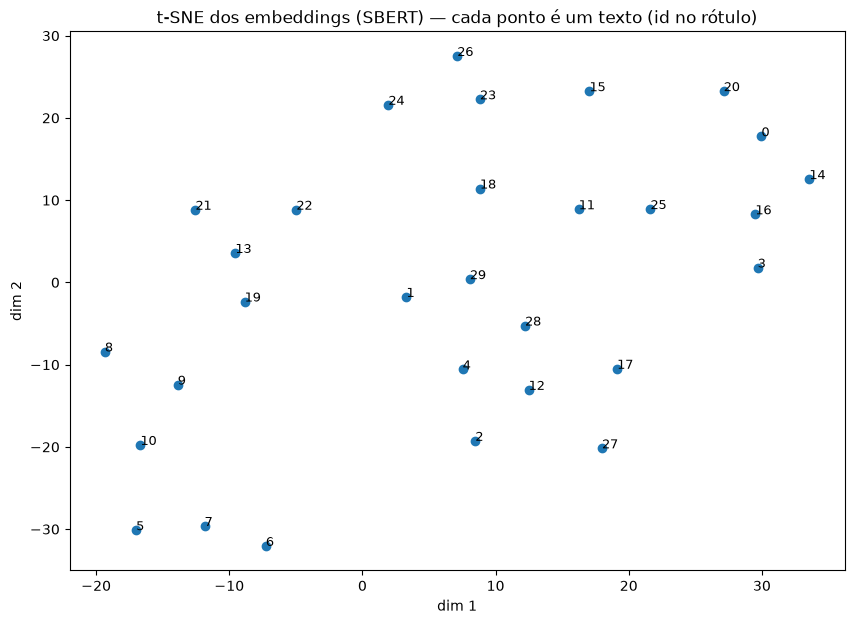

In [5]:
tsne = TSNE(n_components=2, perplexity=10, random_state=42, init='pca', learning_rate='auto')
Z = tsne.fit_transform(X_sbert)

plt.figure(figsize=(10, 7))
plt.scatter(Z[:, 0], Z[:, 1])

for i, _ in enumerate(texts):
    plt.text(Z[i, 0], Z[i, 1], str(i), fontsize=9)

plt.title('t-SNE dos embeddings (SBERT) — cada ponto é um texto (id no rótulo)')
plt.xlabel('dim 1')
plt.ylabel('dim 2')
plt.show()

## 5) O exercício (8.2)

1) Escolha **3–5 textos** que você acha que são do **mesmo tema** (ex.: "infra de TI", "saúde", "viagens", "culinária").
2) Veja se os **IDs** desses textos aparecem **próximos no mapa**.
3) Se não aparecerem, tente:
   - aumentar `perplexity` para **15** ou **20**;
   - ou usar **mais textos** do mesmo tema.

Dica: use a tabela abaixo para conferir qual texto corresponde a cada ID.

In [6]:
df[['id', 'text']]

,id,text
0,0,O Kubernetes organiza aplicações em contêinere...
1,1,BERT é um modelo de linguagem baseado em Trans...
2,2,TF-IDF representa textos como vetores esparsos...
3,3,O Keycloak é uma solução de identidade para au...
4,4,Uma rede neural pode aprender representações ú...
5,5,Esteatose hepática é o acúmulo de gordura no f...
6,6,Exercícios físicos regulares ajudam a melhorar...
7,7,"Uma dieta balanceada inclui proteínas, carboid..."
8,8,"Em Paris, o metrô e o RER conectam pontos turí..."
9,9,"Em Budapeste, os banhos termais são uma atraçã..."


### 5.1 Ferramenta de comparação

Função que plota o t-SNE com uma `perplexity` qualquer. Rode para 15 e 20 e compare.

In [7]:
def plot_tsne(perplexity: int = 10, highlight_ids: list[int] | None = None):
    tsne = TSNE(n_components=2, perplexity=perplexity, random_state=42, init='pca', learning_rate='auto')
    Z = tsne.fit_transform(X_sbert)

    plt.figure(figsize=(10, 7))
    plt.scatter(Z[:, 0], Z[:, 1], alpha=0.6)

    for i, _ in enumerate(texts):
        plt.text(Z[i, 0], Z[i, 1], str(i), fontsize=9)

    if highlight_ids:
        h = list(highlight_ids)
        plt.scatter(Z[h, 0], Z[h, 1], color='red', edgecolors='black', s=120, label='meus textos')
        plt.legend()

    plt.title(f't-SNE (SBERT) — perplexity={perplexity}')
    plt.xlabel('dim 1')
    plt.ylabel('dim 2')
    plt.show()

Textos escolhidos:
[15] Power Automate automatiza fluxos de trabalho integrando serviços do Microsoft 365.
[16] Uma VPN cria um túnel criptografado para acessar recursos internos remotamente.
[20] O GitHub Actions executa pipelines de CI/CD para build e deploy.
[3] O Keycloak é uma solução de identidade para autenticação e single sign-on (SSO).


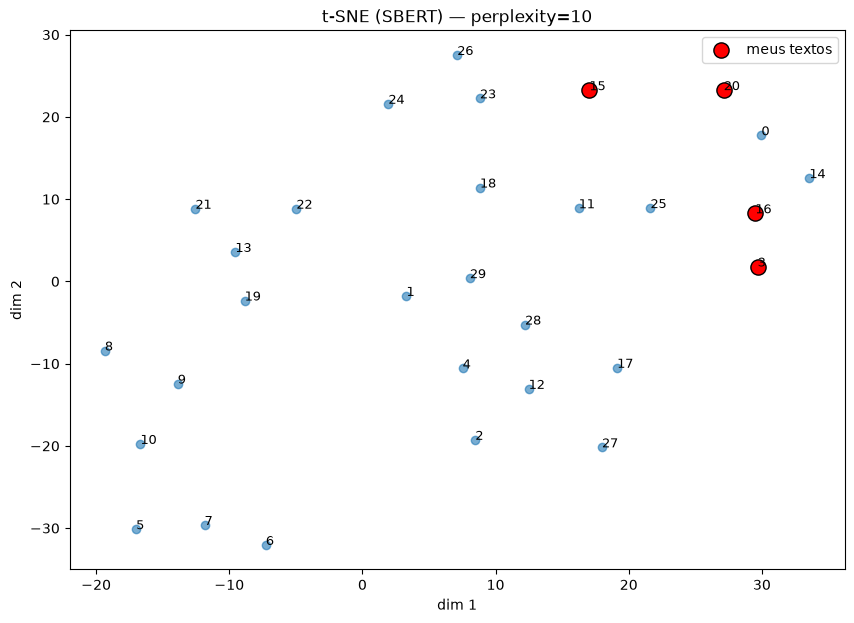

In [8]:
# Escolha 3-5 IDs de textos do mesmo tema (olhe a tabela acima)
meus_ids = [15, 16, 20, 3]  # ex.: infra de TI — edite!

print('Textos escolhidos:')
for i in meus_ids:
    print(f'[{i}] {texts[i]}')

plot_tsne(perplexity=10, highlight_ids=meus_ids)

### 5.2 Compare perplexity

Rode o mesmo conjunto com perplexity **15** e **20** e veja se os agrupamentos mudam.

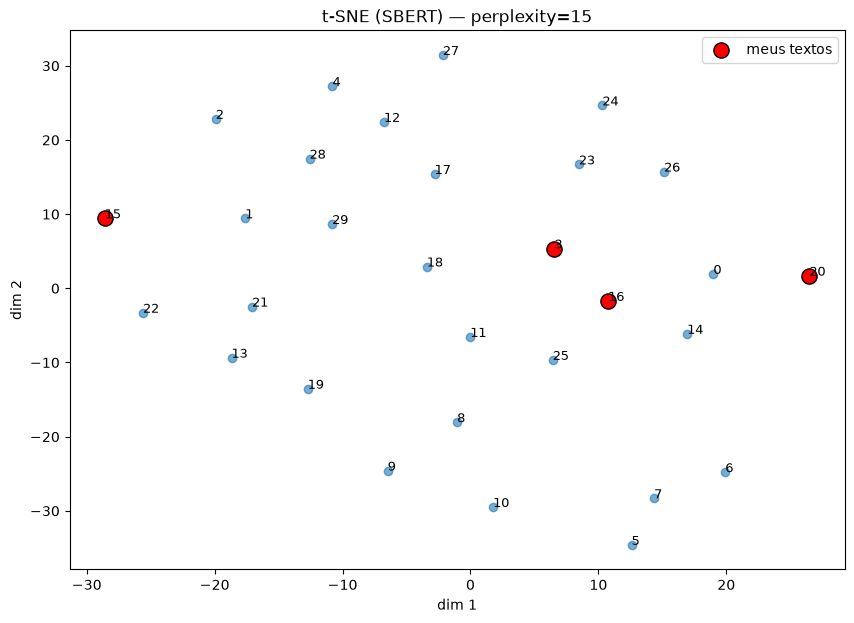

In [9]:
plot_tsne(perplexity=15, highlight_ids=meus_ids)

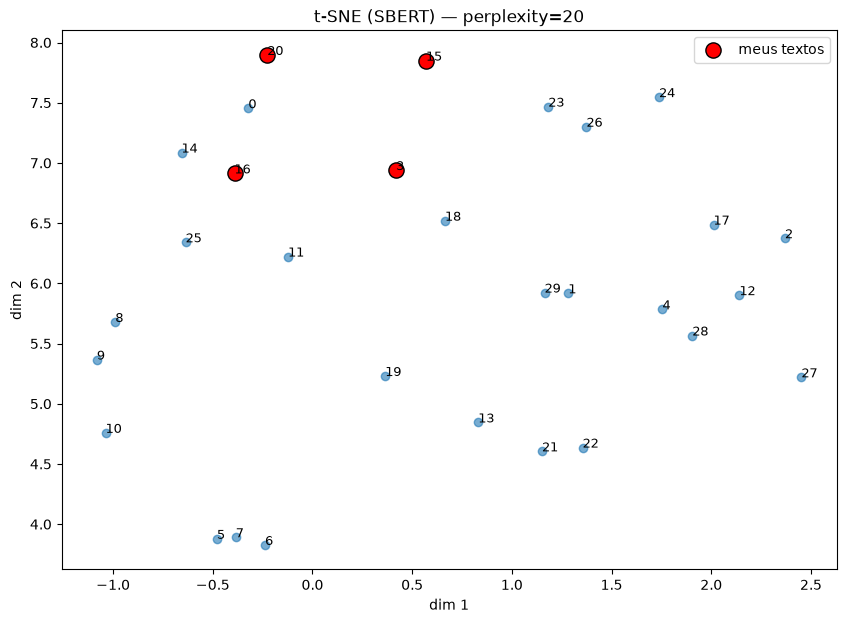

In [10]:
plot_tsne(perplexity=20, highlight_ids=meus_ids)

## 6) Responda

1) Quais **3–5 textos do mesmo tema** você escolheu (IDs)?

R.:


2) Eles apareceram **próximos** no mapa com perplexity=10?

R.:


3) O que **mudou** com perplexity = 15 e 20?

R.:


4) Se não apareceram próximos, o que você tentou? (mais textos do tema? perplexity maior?)

R.:

## 7) Extras (opcional)

- Adicione mais textos do mesmo tema no dataset e rode novamente.
- Compare com o mapa do **PCA** (sklearn `PCA(n_components=2)`) e veja a diferença.
- Teste outros valores de `random_state` para ver como o t-SNE varia.